In [1]:
from dataset_ae import EASGDatasetAE, EASGData
from pathlib import Path
from torch_geometric.loader import DataLoader
import torch

with open('annts_in_new_format/' + 'verbs.txt') as f:
    verbs = [l.strip() for l in f.readlines()]
num_verbs = len(verbs)

with open('annts_in_new_format/' + 'objects.txt') as f:
    objs = [l.strip() for l in f.readlines()]
num_objs = len(objs)

with open('annts_in_new_format/' + 'relationships.txt') as f:
    rels = [l.strip() for l in f.readlines()]
num_rels = len(rels)

path_annts = Path('annts_in_new_format')
path_data = Path('data')

train_original = EASGData(path_annts, path_data, 'train', verbs, objs, rels)
val_original = EASGData(path_annts, path_data, 'val', verbs, objs, rels)
train_dataset = EASGDatasetAE(path_annts, path_data, 'train', verbs, objs, rels)
val_dataset = EASGDatasetAE(path_annts, path_data, 'val', verbs, objs, rels)

batch_size = 1
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 


# Some dataset statistics

### Length of train and validation datasets

In [5]:
print(f"Training dataset containts {len(train_original)} graphs.")
print(f"Validation dataset containts {len(val_original)} graphs.")

Training dataset containts 3822 graphs.
Validation dataset containts 2382 graphs.


### Number of objects in the graphs of train and validation datasets
Keep in mind that the number of nodes for each graph is always equal to the number of objecs+1 because there is always one verb for each graph

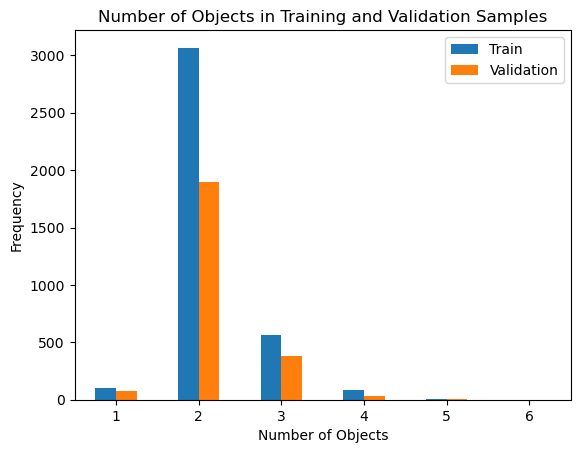

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the number of objects in each training and validation sample
num_objects_train = [len(el['obj_indices']) for el in train_original]       # if you want the number of nodes instead of objects add 1 after len here...
num_objects_val = [len(el['obj_indices']) for el in val_original]           # ...and here

# Convert to pandas Series
objects_train_pd = pd.Series(num_objects_train, name='Train')
objects_val_pd = pd.Series(num_objects_val, name='Validation')

# Get value counts and sort by index
objects_train_count = objects_train_pd.value_counts().sort_index()
objects_val_count = objects_val_pd.value_counts().sort_index()

# Combine both Series into a DataFrame
objects_count_df = pd.DataFrame({'Train': objects_train_count, 'Validation': objects_val_count}).fillna(0)

objects_count_df.plot.bar()
plt.xticks(rotation=0)
plt.title('Number of Objects in Training and Validation Samples')
plt.xlabel('Number of Objects')
plt.ylabel('Frequency')
plt.show()


### Percentage frequency of the most common verbs in the dataset

In [4]:
# length of training and validation dataset
verbs_list_val = []
for el in val_original:
    verbs_list_val.append(el['verb_idx'].item())

verbs_list_train = []
for el in train_original:
    verbs_list_train.append(el['verb_idx'].item())
    
print(len(verbs_list_train))
print(len(verbs_list_val))

3822
2382


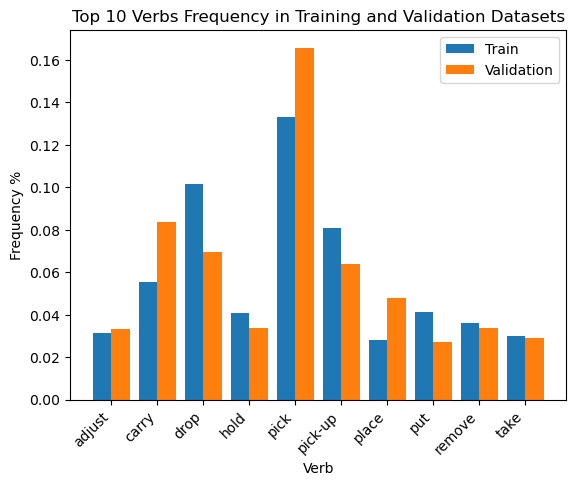

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Create Counters for both train and validation datasets
c_train = Counter(verbs_list_train)
c_val = Counter(verbs_list_val)

# Extract the top 10 verbs for both train and validation datasets
top10_verbs_train = c_train.most_common(10)
top10_verbs_val = c_val.most_common(10)

# Sort the top 10 verbs by their verb ID
top10_verbs_train.sort(key=lambda x: x[0])
top10_verbs_val.sort(key=lambda x: x[0])

# Get the verb names and their frequencies
train_verbs = [verbs[el[0]] for el in top10_verbs_train]
train_perc = [el[1]/len(train_original) for el in top10_verbs_train]
val_verbs = [verbs[el[0]] for el in top10_verbs_val]
val_perc = [el[1]/len(val_original) for el in top10_verbs_val]

# Create a DataFrame to plot
df_train = pd.DataFrame({'Verb': train_verbs, 'Frequency': train_perc, 'Dataset': 'Train'})
df_val = pd.DataFrame({'Verb': val_verbs, 'Frequency': val_perc, 'Dataset': 'Validation'})
df = pd.concat([df_train, df_val])

# Plot the bar chart
fig, ax = plt.subplots()
width = 0.4
x_train = range(len(train_verbs))
x_val = [x + width for x in x_train]

ax.bar(x_train, train_perc, width=width, label='Train')
ax.bar(x_val, val_perc, width=width, label='Validation')

plt.title('Top 10 Verbs Frequency in Training and Validation Datasets')
plt.xlabel('Verb')
plt.ylabel('Frequency %')

ax.set_xticks([x + width / 2 for x in x_train])
ax.set_xticklabels(train_verbs, rotation=45, ha='right')
plt.legend()
plt.show()

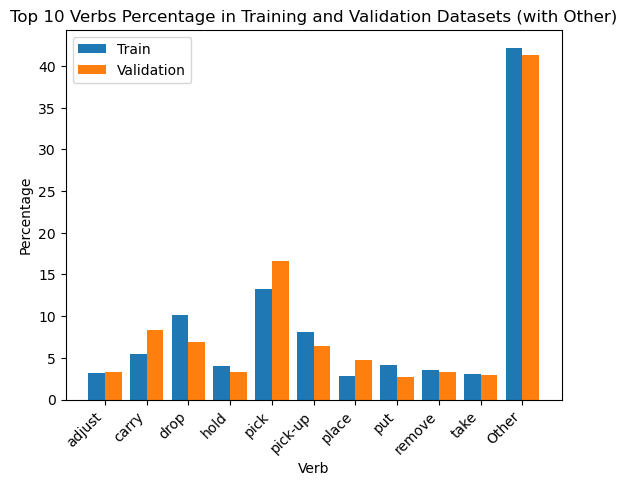

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Create Counters for both train and validation datasets
c_train = Counter(verbs_list_train)
c_val = Counter(verbs_list_val)

# Extract the top 10 verbs for both train and validation datasets
top10_verbs_train = c_train.most_common(10)
top10_verbs_val = c_val.most_common(10)

# Calculate the sum of all other verbs
other_train_count = sum(c_train.values()) - sum(count for verb, count in top10_verbs_train)
other_val_count = sum(c_val.values()) - sum(count for verb, count in top10_verbs_val)

# Append "Other" category
top10_verbs_train.append(('Other', other_train_count))
top10_verbs_val.append(('Other', other_val_count))

# Sort the top 10 verbs by their verb ID
top10_verbs_train.sort(key=lambda x: x[0] if x[0] != 'Other' else float('inf'))
top10_verbs_val.sort(key=lambda x: x[0] if x[0] != 'Other' else float('inf'))

# Get the total counts for calculating percentages
total_train_count = sum(c_train.values())
total_val_count = sum(c_val.values())

# Get the verb names and their percentages
train_verbs = [verbs[el[0]] if el[0] != 'Other' else 'Other' for el in top10_verbs_train]
train_percentages = [el[1] / total_train_count * 100 for el in top10_verbs_train]
val_verbs = [verbs[el[0]] if el[0] != 'Other' else 'Other' for el in top10_verbs_val]
val_percentages = [el[1] / total_val_count * 100 for el in top10_verbs_val]

# Create a DataFrame to plot
df_train = pd.DataFrame({'Verb': train_verbs, 'Percentage': train_percentages, 'Dataset': 'Train'})
df_val = pd.DataFrame({'Verb': val_verbs, 'Percentage': val_percentages, 'Dataset': 'Validation'})
df = pd.concat([df_train, df_val])

# Plot the bar chart
fig, ax = plt.subplots()
width = 0.4
x_train = range(len(train_verbs))
x_val = [x + width for x in x_train]
ax.bar(x_train, train_percentages, width=width, label='Train')
ax.bar(x_val, val_percentages, width=width, label='Validation')

# Set plot title and axis labels
plt.title('Top 10 Verbs Percentage in Training and Validation Datasets (with Other)')
plt.xlabel('Verb')
plt.ylabel('Percentage')
ax.set_xticks([x + width / 2 for x in x_train])
ax.set_xticklabels(train_verbs, rotation=45, ha='right')
plt.legend()
plt.show()

In [ ]:
from collections import Counter
c_val = Counter(verbs_list_val)
c_train = Counter(verbs_list_train)

# 395 is the number of times verb 89 ("picks") appears in the validation dataset
print(c_val.most_common(1)[0][1]/len(val_original))        # = 0.1658 like top1 verb prediction
# 199 is the number of times verb 36 ("drop") appears in the validation dataset
print((c_val.most_common(2)[0][1]+c_val.most_common(2)[1][1])/len(val_original))      # = 0.2493 like top2 verb prediction
# top5 and top10 are a bit different but if I keep summing up I obtain something very similar

top10_verbs_train = [el[0] for el in c_train.most_common(10)]
top10_verbs_train.sort()
print(top10_verbs_train)

top10_verbs_val = [el[0] for el in c_val.most_common(10)]
top10_verbs_val.sort()
print(top10_verbs_val)

print(sum(top10_verbs_val)/len(val_original))
print(sum(top10_verbs_train)/len(val_original))

0.1658270361041142
0.24937027707808565
[1, 12, 36, 58, 89, 91, 92, 108, 115, 162]
[26, 36, 58, 86, 89, 91, 92, 108, 115, 174]
0.36733837111670864
0.32073887489504616


### Percentage frequency of the most common objects in the dataset

### Graphs with multiple relationships objects

In [14]:
# count how many graphs have objects with multiple relationships
count_train = 0
for el in train_original:
    objects = [i.item() for i in el['triplets'][:,1]]
    objects_set = set(objects)
    if len(objects) > len(objects_set):
        count_train +=1

count_val = 0
for el in val_original:
    objects = [i.item() for i in el['triplets'][:,1]]
    objects_set = set(objects)
    if len(objects) > len(objects_set):
        count_val +=1
print(f"Train dataset contains {count_train} graphs with multiple relationships objects ({((count_train*100)/len(train_original)):.2f}%)")
print(f"Validation dataset contains {count_val} graphs with multiple relationships objects ({((count_val*100)/len(train_original)):.2f}%)")


Train dataset contains 186 graphs with multiple relationships objects (4.87%)
Validation dataset contains 166 graphs with multiple relationships objects (4.34%)
